# Multi-seed Multipath DLGN Experiments (5 seeds)

This notebook runs the multipath workflow from `scratch.ipynb` across 5 master seeds.

Per seed run modes:
- `two_phase_phase1`
- `two_phase_phase2_nozero`
- `two_phase_phase2_zeroed`
- `one_phase`

Design goals:
- Reduce checkpoint memory by using `snapshot_stride=200`.
- Keep the ability to draw scatter plots at any checkpoint epoch.
- Produce aggregate summaries across seeds and run modes.

In [1]:
import copy
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from first_experiment.odt import generate_cob_odt_data
from first_experiment.dlgn import DLGNSF
from first_experiment.training import (
    TrainConfig,
    train_dlgn_sf,
    evaluate_dlgn_sf,
    effective_gating_weights_from_checkpoint,
    set_seed,
)

## Global settings (aligned with current scratch defaults)

This block keeps architecture and data scale consistent with your existing experiments, while changing checkpoint stride to 200 for memory convenience.

In [2]:
# ---- Core settings ----
DIM = 100
DEPTH = 5
N_TRAIN = 80_000
HIDDEN_DIMS = [16, 16, 16, 16, 16]
BETA = 11.0

TOTAL_EPOCHS = 4000
PHASE1_EPOCHS = TOTAL_EPOCHS // 2
PHASE2_EPOCHS = TOTAL_EPOCHS - PHASE1_EPOCHS

SNAPSHOT_STRIDE = 200
CHECKPOINT_EPOCHS_PHASE1 = tuple(range(0, PHASE1_EPOCHS + 1, SNAPSHOT_STRIDE))
CHECKPOINT_EPOCHS_PHASE2 = tuple(range(0, PHASE2_EPOCHS + 1, SNAPSHOT_STRIDE))
CHECKPOINT_EPOCHS_ONE = tuple(range(0, TOTAL_EPOCHS + 1, SNAPSHOT_STRIDE))

DEVICE = "cpu"
GATING_NORM_ZERO_THRESHOLD = 2.5

# 5 master seeds
MASTER_SEEDS = [5178, 6178, 7178, 8178, 9178]

SEED_OFFSETS = {
    "data": 0,
    "init": 1000,
    "phase1_train": 2000,
    "phase2_train": 2001,
    "one_phase_train": 2002,
}

def derive_seed_bundle(master_seed: int) -> dict:
    return {
        "master_seed": master_seed,
        "data_seed": master_seed + SEED_OFFSETS["data"],
        "init_seed": master_seed + SEED_OFFSETS["init"],
        "phase1_train_seed": master_seed + SEED_OFFSETS["phase1_train"],
        "phase2_train_seed": master_seed + SEED_OFFSETS["phase2_train"],
        "one_phase_train_seed": master_seed + SEED_OFFSETS["one_phase_train"],
    }

def make_model() -> DLGNSF:
    return DLGNSF(
        input_dim=DIM,
        hidden_dims=HIDDEN_DIMS,
        beta=BETA,
        bias=False,
        value_input_mode="ones",
        gating_weight_scale=1.0,
        value_weight_scale=1.0,
    )

## Helpers

These functions run all branches for one seed, and provide utility functions for gating-vector scatter plots from checkpoint snapshots.

In [13]:
def stack_gating_numpy(gating_weights: list[torch.Tensor]) -> np.ndarray:
    return np.concatenate([w.detach().cpu().numpy() for w in gating_weights], axis=0)


def neuron_alignment_stats(gating_vecs: np.ndarray, odt_normals: np.ndarray):
    norms = np.linalg.norm(gating_vecs, axis=1)
    gv_norm = np.linalg.norm(gating_vecs, axis=1, keepdims=True) + 1e-12
    odt_norm = np.linalg.norm(odt_normals, axis=1, keepdims=True).T + 1e-12
    cos = (gating_vecs @ odt_normals.T) / (gv_norm * odt_norm)
    maxcos = np.max(np.abs(cos), axis=1)
    closest = np.argmax(np.abs(cos), axis=1)
    return norms, maxcos, closest


def regenerate_split_from_seed(data_seed: int):
    x, y, _, _ = generate_cob_odt_data(
        num_data=2 * N_TRAIN,
        dim=DIM,
        depth=DEPTH,
        seed=data_seed,
        threshold=0.0,
    )
    return x[:N_TRAIN], y[:N_TRAIN], x[N_TRAIN:], y[N_TRAIN:]


def run_single_seed_with_checkpoints(master_seed: int) -> dict:
    seeds = derive_seed_bundle(master_seed)

    x, y, tree, meta = generate_cob_odt_data(
        num_data=2 * N_TRAIN,
        dim=DIM,
        depth=DEPTH,
        seed=seeds["data_seed"],
        threshold=0.0,
    )
    x_train, y_train = x[:N_TRAIN], y[:N_TRAIN]
    x_eval, y_eval = x[N_TRAIN:], y[N_TRAIN:]

    # Phase 1 (shared base)
    set_seed(seeds["init_seed"])
    model_two_phase = make_model()

    train_cfg_phase1 = TrainConfig(
        epochs=PHASE1_EPOCHS,
        lr=1e-3,
        batch_size=N_TRAIN // 500,
        seed=seeds["phase1_train_seed"],
        device=DEVICE,
        snapshot_epochs=CHECKPOINT_EPOCHS_PHASE1,
        show_progress=False,
        weight_decay_gating=2e-4,
        weight_decay_value=0.0,
        lr_scheduler="cosine",
        lr_scheduler_eta_min_ratio=0.2,
    )
    out_two_phase_phase1 = train_dlgn_sf(
        model=model_two_phase,
        x_train=x_train,
        y_train=y_train,
        config=train_cfg_phase1,
    )
    phase1_model_base = out_two_phase_phase1["model"]

    # Phase 2 (no zeroing)
    train_cfg_phase2 = TrainConfig(
        epochs=PHASE2_EPOCHS,
        lr=1e-3,
        batch_size=N_TRAIN // 500,
        seed=seeds["phase2_train_seed"],
        device=DEVICE,
        snapshot_epochs=CHECKPOINT_EPOCHS_PHASE2,
        show_progress=False,
        weight_decay_gating=0.0,
        weight_decay_value=0.0,
        lr_scheduler="cosine",
        lr_scheduler_eta_min_ratio=0.2,
    )
    out_two_phase_phase2_nozero = train_dlgn_sf(
        model=copy.deepcopy(phase1_model_base),
        x_train=x_train,
        y_train=y_train,
        config=train_cfg_phase2,
    )

    # Phase 2 (zeroed + frozen)
    phase2_model_zeroed = copy.deepcopy(phase1_model_base)
    with torch.no_grad():
        for layer in phase2_model_zeroed.gating_layers:
            row_norms = layer.weight.norm(dim=1)
            keep_mask = row_norms >= GATING_NORM_ZERO_THRESHOLD
            layer.weight[~keep_mask, :] = 0.0

    train_cfg_phase2_zeroed = TrainConfig(
        epochs=PHASE2_EPOCHS,
        lr=1e-3,
        batch_size=N_TRAIN // 500,
        seed=seeds["phase2_train_seed"],
        device=DEVICE,
        snapshot_epochs=CHECKPOINT_EPOCHS_PHASE2,
        show_progress=False,
        weight_decay_gating=0.0,
        weight_decay_value=0.0,
        lr_scheduler="cosine",
        lr_scheduler_eta_min_ratio=0.2,
        freeze_zero_gating_rows=True,
    )
    out_two_phase_phase2_zeroed = train_dlgn_sf(
        model=phase2_model_zeroed,
        x_train=x_train,
        y_train=y_train,
        config=train_cfg_phase2_zeroed,
    )

    # One-phase baseline
    set_seed(seeds["init_seed"])
    model_one_phase = make_model()

    train_cfg_one_phase = TrainConfig(
        epochs=TOTAL_EPOCHS,
        lr=1e-3,
        batch_size=N_TRAIN // 500,
        seed=seeds["one_phase_train_seed"],
        device=DEVICE,
        snapshot_epochs=CHECKPOINT_EPOCHS_ONE,
        show_progress=False,
        weight_decay_gating=0.0,
        weight_decay_value=0.0,
        lr_scheduler="cosine",
        lr_scheduler_eta_min_ratio=0.2,
    )
    out_one_phase = train_dlgn_sf(
        model=model_one_phase,
        x_train=x_train,
        y_train=y_train,
        config=train_cfg_one_phase,
    )

    return {
        "seeds": seeds,
        "tree": tree,
        "meta": meta,
        "runs": {
            "two_phase_phase1": {"out": out_two_phase_phase1, "train_cfg": train_cfg_phase1},
            "two_phase_phase2_nozero": {"out": out_two_phase_phase2_nozero, "train_cfg": train_cfg_phase2},
            "two_phase_phase2_zeroed": {"out": out_two_phase_phase2_zeroed, "train_cfg": train_cfg_phase2_zeroed},
            "one_phase": {"out": out_one_phase, "train_cfg": train_cfg_one_phase},
        },
    }


def plot_scatter_for_checkpoint(all_results: Dict[int, dict], master_seed: int, run_mode: str, epoch: int, figsize=(7, 5)):
    seed_result = all_results[master_seed]
    run_block = seed_result["runs"][run_mode]
    out = run_block["out"]
    checkpoint_snapshots = out["checkpoint_snapshots"]

    if epoch not in checkpoint_snapshots:
        available = sorted(checkpoint_snapshots.keys())
        raise ValueError(f"epoch={epoch} not available. Available checkpoints: {available}")

    model_template = out["model"]
    gw = effective_gating_weights_from_checkpoint(model_template, checkpoint_snapshots[epoch])
    gw_stack = stack_gating_numpy(gw)

    odt_normals = seed_result["tree"].w_list
    norms, maxcos, closest = neuron_alignment_stats(gw_stack, odt_normals)

    plt.figure(figsize=figsize)
    cmap = plt.get_cmap("tab20", odt_normals.shape[0])
    sc = plt.scatter(norms, maxcos, c=closest, s=9, alpha=0.75, cmap=cmap)
    plt.xlabel("||gating vector||")
    plt.ylabel("max |cosine| to ODT normals")
    plt.title(f"Seed={master_seed} | Mode={run_mode} | Epoch={epoch}")
    plt.colorbar(sc, label="Closest ODT normal index")
    plt.grid(alpha=0.2)
    plt.show()

## Run checkpoint-rich experiments for all 5 seeds

This stores checkpoint snapshots needed for scatter plots.

Note: this can take time and memory depending on your environment.

In [4]:
all_results: Dict[int, dict] = {}

for ms in MASTER_SEEDS:
    print(f"Running master seed: {ms}")
    all_results[ms] = run_single_seed_with_checkpoints(ms)

print("Done.")

Running master seed: 5178
Running master seed: 6178
Running master seed: 7178
Running master seed: 8178
Running master seed: 9178
Done.


In [ ]:
# saving results to pickle file
from pathlib import Path
import gzip
import pickle
from datetime import datetime

save_dir = Path("results/notebook_cache")
save_dir.mkdir(parents=True, exist_ok=True)

tag = datetime.now().strftime("%Y%m%dT%H%M%S")
save_path = save_dir / f"all_results_{tag}.pkl.gz"

with gzip.open(save_path, "wb") as f:
    pickle.dump(all_results, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved: {save_path}")

Saved: results/notebook_cache/all_results_20260424T082911.pkl.gz


In [ ]:
## Loading from pickle file.
# from pathlib import Path
# import gzip
# import pickle

# # replace with your chosen file
# load_path = Path("results/notebook_cache/all_results_YYYYMMDDTHHMMSS.pkl.gz")

# with gzip.open(load_path, "rb") as f:
#     all_results = pickle.load(f)

# print(f"Loaded keys (master seeds): {list(all_results.keys())}")

## Scatter plots: any seed, mode, checkpoint

Pick any seed from `MASTER_SEEDS`, run mode, and available checkpoint epoch.

Run modes:
- `two_phase_phase1`
- `two_phase_phase2_nozero`
- `two_phase_phase2_zeroed`
- `one_phase`

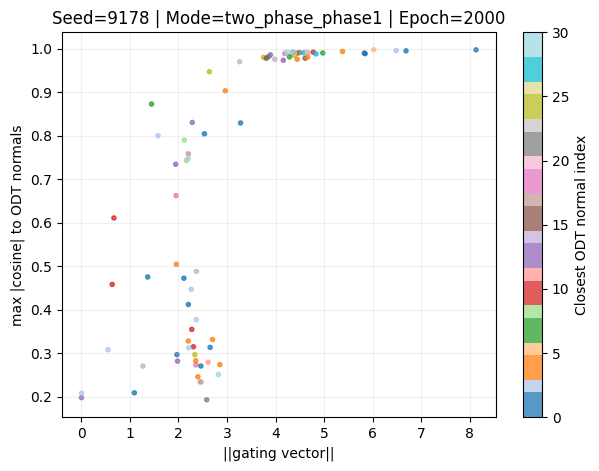

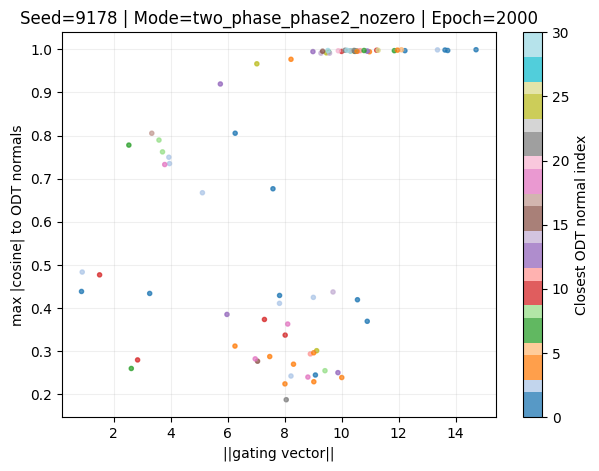

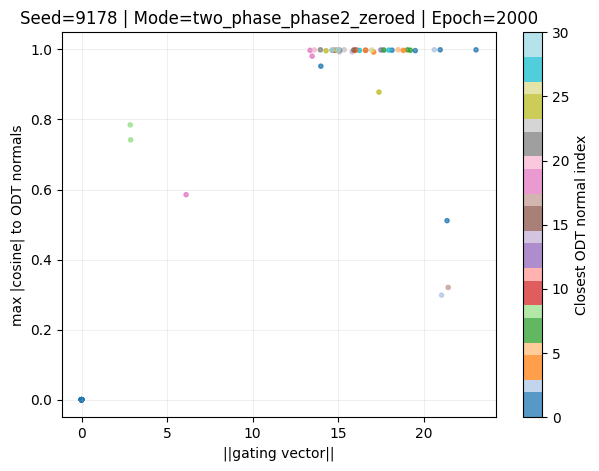

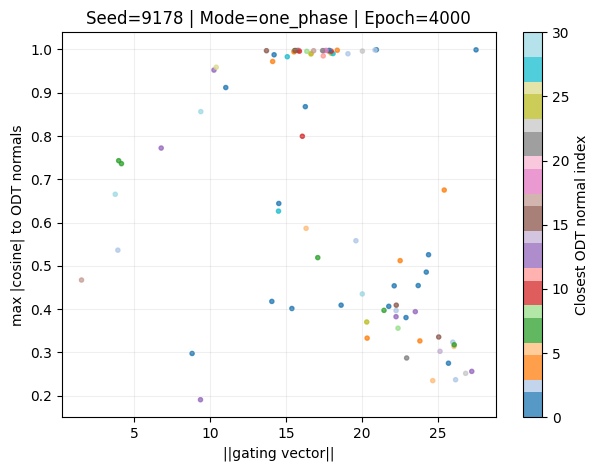

In [10]:
# Example calls
mseed = MASTER_SEEDS[4]
plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="two_phase_phase1", epoch=2000)
plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="two_phase_phase2_nozero", epoch=2000)
plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="two_phase_phase2_zeroed", epoch=2000)
plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="one_phase", epoch=4000)

## Start/end metrics from checkpoints for all seeds and modes

This computes (per seed, per mode):
- training log loss at start and end checkpoint
- test error (zero-one loss) at start and end checkpoint

Then it aggregates mean/std across seeds.

In [14]:
rows = []

for master_seed, seed_result in all_results.items():
    data_seed = seed_result["seeds"]["data_seed"]
    x_train, y_train, x_eval, y_eval = regenerate_split_from_seed(data_seed)

    for run_mode, run_block in seed_result["runs"].items():
        out = run_block["out"]
        ckpts = out["checkpoint_snapshots"]
        epochs_sorted = sorted(ckpts.keys())
        e0, eN = epochs_sorted[0], epochs_sorted[-1]

        eval_model = copy.deepcopy(out["model"]).to(DEVICE)

        for label, ep in [("start", e0), ("end", eN)]:
            eval_model.load_state_dict(ckpts[ep])

            m_tr = evaluate_dlgn_sf(model=eval_model, x_eval=x_train, y_eval=y_train, device=DEVICE)
            m_te = evaluate_dlgn_sf(model=eval_model, x_eval=x_eval, y_eval=y_eval, device=DEVICE)

            rows.append(
                {
                    "master_seed": master_seed,
                    "run_mode": run_mode,
                    "timepoint": label,
                    "epoch": ep,
                    "train_log_loss": m_tr["log_loss"],
                    "test_error": m_te["zero_one_loss"],
                }
            )

stats_df = pd.DataFrame(rows)
per_seed_table = stats_df.sort_values(["run_mode", "master_seed", "timepoint"]).reset_index(drop=True)

agg_table = (
    stats_df.groupby(["run_mode", "timepoint"], as_index=False)
    .agg(
        n=("master_seed", "count"),
        train_log_loss_mean=("train_log_loss", "mean"),
        train_log_loss_std=("train_log_loss", "std"),
        test_error_mean=("test_error", "mean"),
        test_error_std=("test_error", "std"),
    )
    .sort_values(["run_mode", "timepoint"])
    .reset_index(drop=True)
)

display(per_seed_table)
display(agg_table)

,master_seed,run_mode,timepoint,epoch,train_log_loss,test_error
0,5178,one_phase,end,4000,1.660501e-03,0.141438
1,5178,one_phase,start,0,6.931466e-01,0.496388
2,6178,one_phase,end,4000,1.145372e-01,0.187525
3,6178,one_phase,start,0,6.931576e-01,0.503550
4,7178,one_phase,end,4000,6.412420e-04,0.156775
5,7178,one_phase,start,0,6.931372e-01,0.490912
6,8178,one_phase,end,4000,8.960279e-03,0.143300
7,8178,one_phase,start,0,6.931483e-01,0.498675
8,9178,one_phase,end,4000,3.205975e-03,0.154913
9,9178,one_phase,start,0,6.931428e-01,0.494213


,run_mode,timepoint,n,train_log_loss_mean,train_log_loss_std,test_error_mean,test_error_std
0,one_phase,end,5,2.580104e-02,4.970925e-02,0.156790,0.018479
1,one_phase,start,5,6.931465e-01,7.498421e-06,0.496747,0.004759
2,two_phase_phase1,end,5,2.488563e-02,1.954481e-02,0.127870,0.005842
3,two_phase_phase1,start,5,6.931465e-01,7.498421e-06,0.496747,0.004759
4,two_phase_phase2_nozero,end,5,3.204684e-07,6.259445e-07,0.086913,0.006780
5,two_phase_phase2_nozero,start,5,2.488563e-02,1.954481e-02,0.127870,0.005842
6,two_phase_phase2_zeroed,end,5,1.357426e-02,1.962925e-02,0.058385,0.008594
7,two_phase_phase2_zeroed,start,5,3.021278e+00,9.661583e-01,0.157790,0.021454
